In [1]:
import sys
import os

while not os.path.isdir("src") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

sys.path.insert(0, "src")

import numpy as np
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.indicators import sma

In [2]:
feed = DataFeed.from_dir("data/egx")

print("Available stocks:")
print(feed.symbols)

Available stocks:
['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']


In [3]:
symbol = "ABUK"

i = feed.symbols.index(symbol)

dates = feed.dates
close = feed.close[:, i]

print("Symbol:", symbol)
print("Number of days:", len(dates))
print("First 5 prices:", close[:5])

Symbol: ABUK
Number of days: 1159
First 5 prices: [19.70000076 21.77000046 21.98999977 22.27000046 21.63999939]


In [4]:
ma9 = sma(close, 9)
ma20 = sma(close, 20)

In [5]:
print("MA9:", ma9[-5:])
print("MA20:", ma20[-5:])

MA9: [72.40111118 72.66777717 72.46888818 72.39333259 72.31555515]
MA20: [70.54900017 70.66899986 70.85499954 71.07599945 71.34599953]


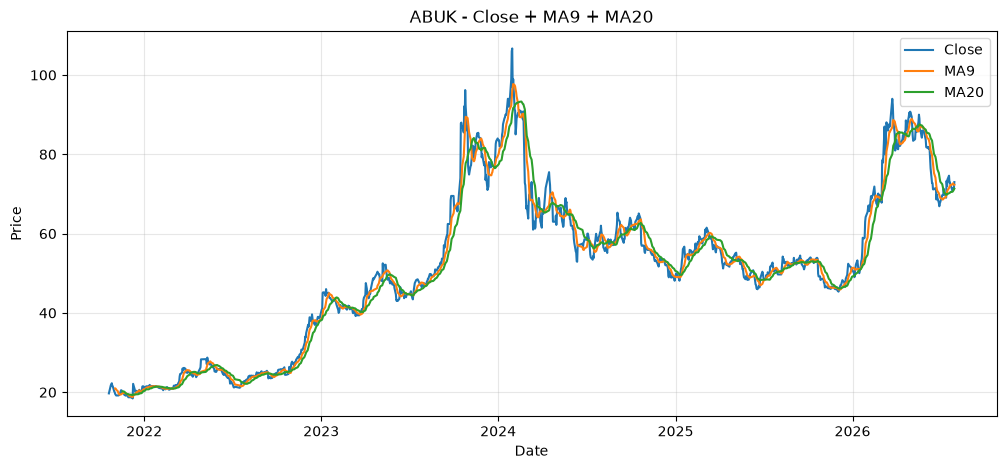

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(dates, close, label="Close")
plt.plot(dates, ma9, label="MA9")
plt.plot(dates, ma20, label="MA20")

plt.title(f"{symbol} - Close + MA9 + MA20")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [7]:
position = 0
buy_dates = []
sell_dates = []
buy_prices = []
sell_prices = []

In [8]:
for t in range(len(close)):

    if np.isnan(ma9[t]) or np.isnan(ma20[t]):
        continue

    if ma9[t] > ma20[t] and position == 0:
        position = 1
        buy_dates.append(dates[t])
        buy_prices.append(close[t])

    elif ma9[t] < ma20[t] and position == 1:
        position = 0
        sell_dates.append(dates[t])
        sell_prices.append(close[t])

In [9]:
print("Number of BUY operations:", len(buy_dates))
print("Number of SELL operations:", len(sell_dates))

Number of BUY operations: 33
Number of SELL operations: 32


In [10]:
initial_cash = 1000

cash = initial_cash
shares = 0

portfolio_values = []

buy_dates = []
sell_dates = []

buy_prices = []
sell_prices = []

In [11]:
for t in range(len(close)):

    price = close[t]

    if np.isnan(ma9[t]) or np.isnan(ma20[t]):
        portfolio_values.append(cash + shares * price)
        continue

    # BUY
    if ma9[t] > ma20[t] and shares == 0:
        shares = cash / price
        cash = 0

        buy_dates.append(dates[t])
        buy_prices.append(price)

    # SELL
    elif ma9[t] < ma20[t] and shares > 0:
        cash = shares * price
        shares = 0

        sell_dates.append(dates[t])
        sell_prices.append(price)

    # قيمة المحفظة في هذا اليوم
    portfolio_value = cash + shares * price
    portfolio_values.append(portfolio_value)

In [12]:
final_value = cash + shares * close[-1]

print("Initial capital:", initial_cash)
print("Final portfolio value:", final_value)

Initial capital: 1000
Final portfolio value: 2855.1741003308343


In [13]:
shares = cash / price

In [14]:
final_value = cash + shares * close[-1]

In [15]:
profit = final_value - initial_cash
return_pct = (profit / initial_cash) * 100

print(f"Initial portfolio value: {initial_cash:.2f} EGP")
print(f"Final portfolio value: {final_value:.2f} EGP")
print(f"Profit / Loss: {profit:.2f} EGP")
print(f"Return: {return_pct:.2f}%")

Initial portfolio value: 1000.00 EGP
Final portfolio value: 0.00 EGP
Profit / Loss: -1000.00 EGP
Return: -100.00%


In [18]:
print("cash:", cash)
print("shares:", shares)
print("last close:", close[-1])
print("final value:", cash + shares * close[-1])

cash: 0
shares: 0.0
last close: 73.0
final value: 0.0


In [17]:
print("BUY operations:", len(buy_dates))
print("SELL operations:", len(sell_dates))

print("\nLast BUY:")
if buy_dates:
    print(buy_dates[-1], buy_prices[-1])

print("\nLast SELL:")
if sell_dates:
    print(sell_dates[-1], sell_prices[-1])

BUY operations: 33
SELL operations: 32

Last BUY:
2026-07-14 00:00:00 73.30999755859375

Last SELL:
2026-06-01 00:00:00 83.5999984741211


In [19]:
initial_cash = 1000.0

cash = initial_cash
shares = 0.0

portfolio_values = []

buy_dates = []
sell_dates = []

buy_prices = []
sell_prices = []

for t in range(len(close)):

    price = close[t]

    # قيمة المحفظة في بداية اليوم
    portfolio_value = cash + shares * price

    if np.isnan(ma9[t]) or np.isnan(ma20[t]):
        portfolio_values.append(portfolio_value)
        continue

    # BUY
    if ma9[t] > ma20[t] and shares == 0 and cash > 0:

        shares = cash / price
        cash = 0.0

        buy_dates.append(dates[t])
        buy_prices.append(price)

    # SELL
    elif ma9[t] < ma20[t] and shares > 0:

        cash = shares * price
        shares = 0.0

        sell_dates.append(dates[t])
        sell_prices.append(price)

    # Portfolio value after today's action
    portfolio_value = cash + shares * price
    portfolio_values.append(portfolio_value)


final_value = cash + shares * close[-1]

print(f"Cash: {cash:.2f}")
print(f"Shares: {shares:.4f}")
print(f"Last close: {close[-1]:.2f}")
print(f"Final portfolio value: {final_value:.2f}")
print(f"BUY operations: {len(buy_dates)}")
print(f"SELL operations: {len(sell_dates)}")

Cash: 0.00
Shares: 39.1120
Last close: 73.00
Final portfolio value: 2855.17
BUY operations: 33
SELL operations: 32


In [20]:
portfolio_values = np.array(portfolio_values)

peak = np.maximum.accumulate(portfolio_values)

drawdown = (portfolio_values - peak) / peak

max_drawdown = drawdown.min()

max_drawdown_pct = max_drawdown * 100

print(f"Maximum Drawdown: {max_drawdown_pct:.2f}%")

Maximum Drawdown: -48.23%


In [21]:
dates
close
ma9
ma20
buy_dates
buy_prices
sell_dates
sell_prices

[np.float64(19.15999984741211),
 np.float64(21.13999938964844),
 np.float64(20.8700008392334),
 np.float64(24.209999084472656),
 np.float64(25.25),
 np.float64(23.899999618530277),
 np.float64(24.5),
 np.float64(43.02999877929688),
 np.float64(41.09000015258789),
 np.float64(47.43000030517578),
 np.float64(44.54999923706055),
 np.float64(44.61000061035156),
 np.float64(78.5),
 np.float64(78.05000305175781),
 np.float64(90.5),
 np.float64(65.4000015258789),
 np.float64(62.20000076293945),
 np.float64(61.970001220703125),
 np.float64(53.83000183105469),
 np.float64(55.650001525878906),
 np.float64(61.45000076293945),
 np.float64(56.91999816894531),
 np.float64(56.04999923706055),
 np.float64(51.0),
 np.float64(49.70000076293945),
 np.float64(52.81999969482422),
 np.float64(51.47999954223633),
 np.float64(49.900001525878906),
 np.float64(67.80000305175781),
 np.float64(82.5999984741211),
 np.float64(85.5999984741211),
 np.float64(83.5999984741211)]

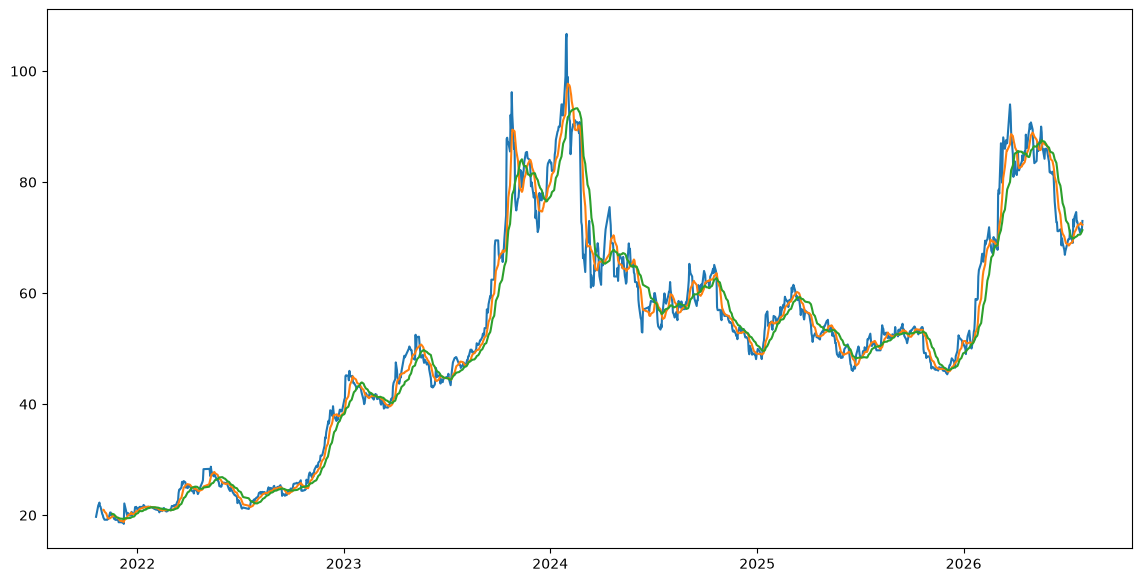

In [22]:
plt.figure(figsize=(14, 7))

plt.plot(dates, close, label="Close")
plt.plot(dates, ma9, label="MA9")
plt.plot(dates, ma20, label="MA20")

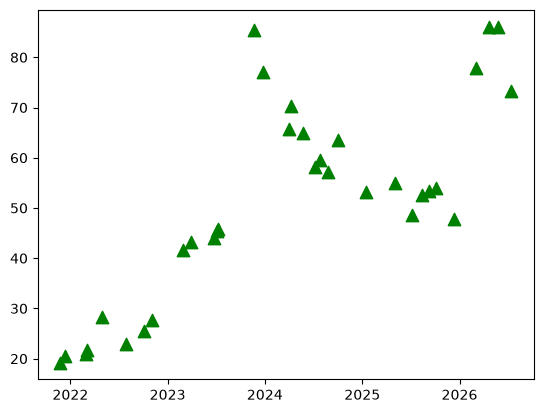

In [23]:
plt.scatter(
    buy_dates,
    buy_prices,
    marker="^",
    color="green",
    s=80,
    label="BUY"
)

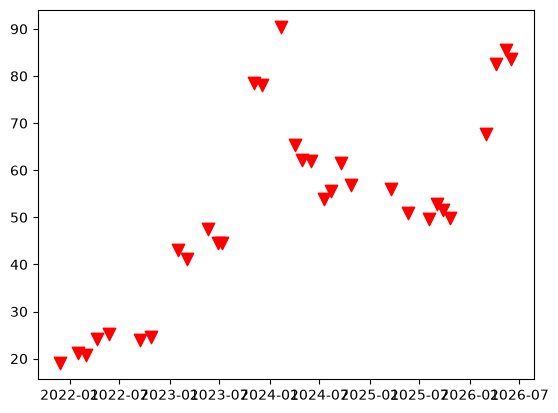

In [24]:
plt.scatter(
    sell_dates,
    sell_prices,
    marker="v",
    color="red",
    s=80,
    label="SELL"
)

In [27]:
print("dates:", len(dates))
print("close:", len(close))
print("ma9:", len(ma9))
print("ma20:", len(ma20))

print("close first:", close[:5])
print("ma9 first:", ma9[:25])
print("ma20 first:", ma20[:25])

dates: 1159
close: 1159
ma9: 1159
ma20: 1159
close first: [19.70000076 21.77000046 21.98999977 22.27000046 21.63999939]
ma9 first: [        nan         nan         nan         nan         nan         nan
         nan         nan 20.95777787 20.92333327 20.63555548 20.32333332
 19.97999997 19.70666673 19.48444451 19.3922223  19.44777785 19.55000008
 19.61777793 19.70888901 19.80000008 19.81666671 19.8388888  19.80111101
 19.78444417]
ma20 first: [        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan 20.22850008 20.24350004 20.12150002 19.99099998 19.83549995
 19.71449995]


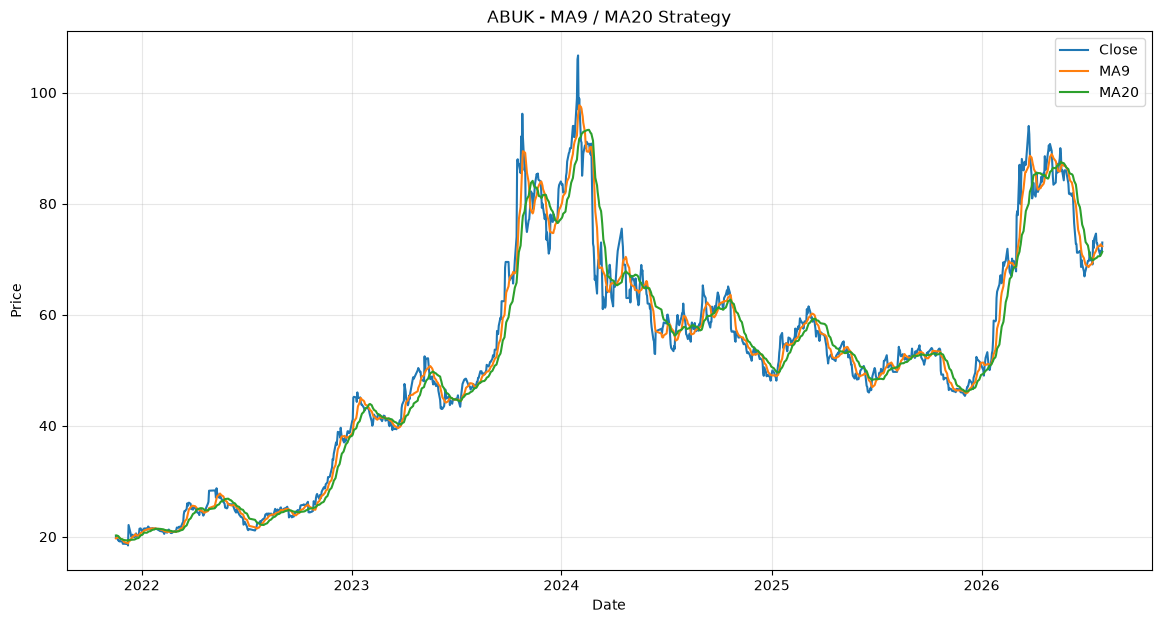

In [29]:
valid = ~np.isnan(ma20)

plt.figure(figsize=(14, 7))

plt.plot(
    np.array(dates)[valid],
    close[valid],
    label="Close"
)

plt.plot(
    np.array(dates)[valid],
    ma9[valid],
    label="MA9"
)

plt.plot(
    np.array(dates)[valid],
    ma20[valid],
    label="MA20"
)

plt.title(f"{symbol} - MA9 / MA20 Strategy")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

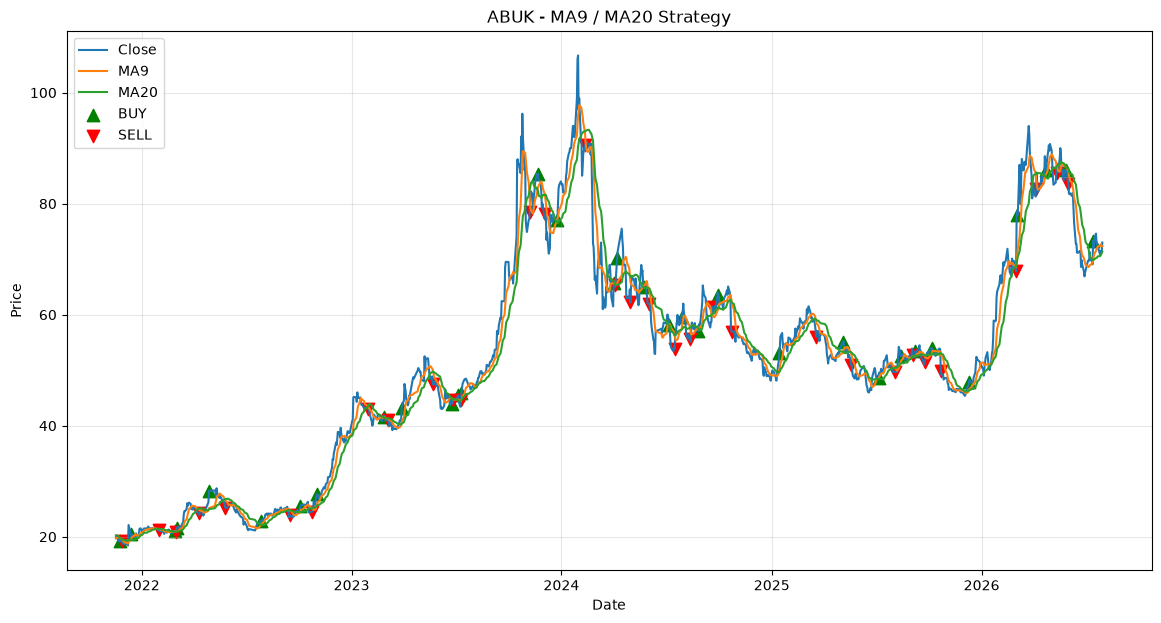

In [30]:
valid = ~np.isnan(ma20)

plt.figure(figsize=(14, 7))

# Close
plt.plot(
    np.array(dates)[valid],
    close[valid],
    label="Close"
)

# MA9
plt.plot(
    np.array(dates)[valid],
    ma9[valid],
    label="MA9"
)

# MA20
plt.plot(
    np.array(dates)[valid],
    ma20[valid],
    label="MA20"
)

# BUY signals
plt.scatter(
    buy_dates,
    buy_prices,
    marker="^",
    color="green",
    s=80,
    label="BUY"
)

# SELL signals
plt.scatter(
    sell_dates,
    sell_prices,
    marker="v",
    color="red",
    s=80,
    label="SELL"
)

plt.title(f"{symbol} - MA9 / MA20 Strategy")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(alpha=0.3)

plt.show()